In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

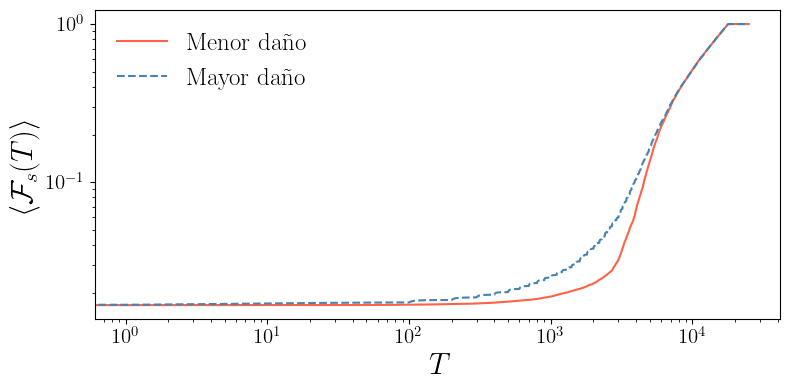

In [2]:
avg_repair = np.load('F_Deterministic_enlace.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
delta_r = 0.01

strategies = ['best', 'worst']

strategy_config = {
    'best':  ('Menor daño', 'tomato', '-', 1.5),
    'worst': ('Mayor daño',  'steelblue', '--', 1.5),
}

# --- TIEMPO ---
t_repair = np.arange(T_repair + 1)

# --- FIGURA ---
plt.figure(figsize=(8, 4), facecolor="white")

# --- CURVAS ---
for s in strategies:
    label, color, style, lw = strategy_config[s]

    plt.loglog(
        t_repair,
        avg_repair[s],
        linestyle=style,
        color=color,
        linewidth=lw,
        label=label
    )

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- LEYENDA ---
plt.legend(
    loc='upper left',
    frameon=False,
    fontsize=18
)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Determinista_enlace.pdf',
            bbox_inches="tight")

plt.show()

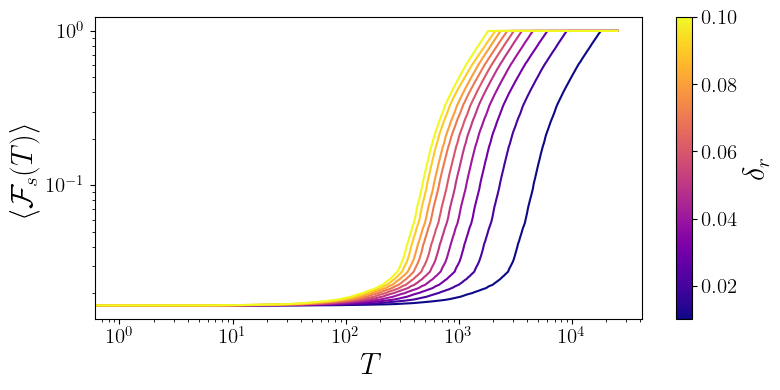

In [4]:
avg_repair = np.load('F_Deterministic_deltar_enlace_Best.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(8, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Determinista_delta_r_enlace_best.pdf',
            bbox_inches="tight")

plt.show()

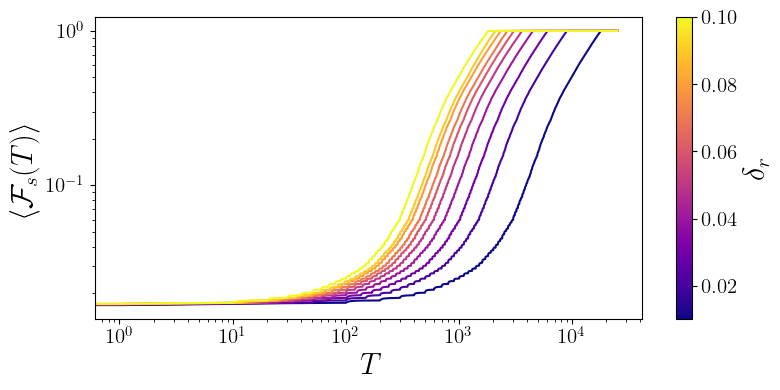

In [5]:
avg_repair = np.load('F_Deterministic_deltar_enlace_Worst.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(8, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Determinista_delta_r_enlace_best_worst.pdf',
            bbox_inches="tight")

plt.show()

C:\Users\Kevin\AppData\Local\Temp\ipykernel_29080\3015464473.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


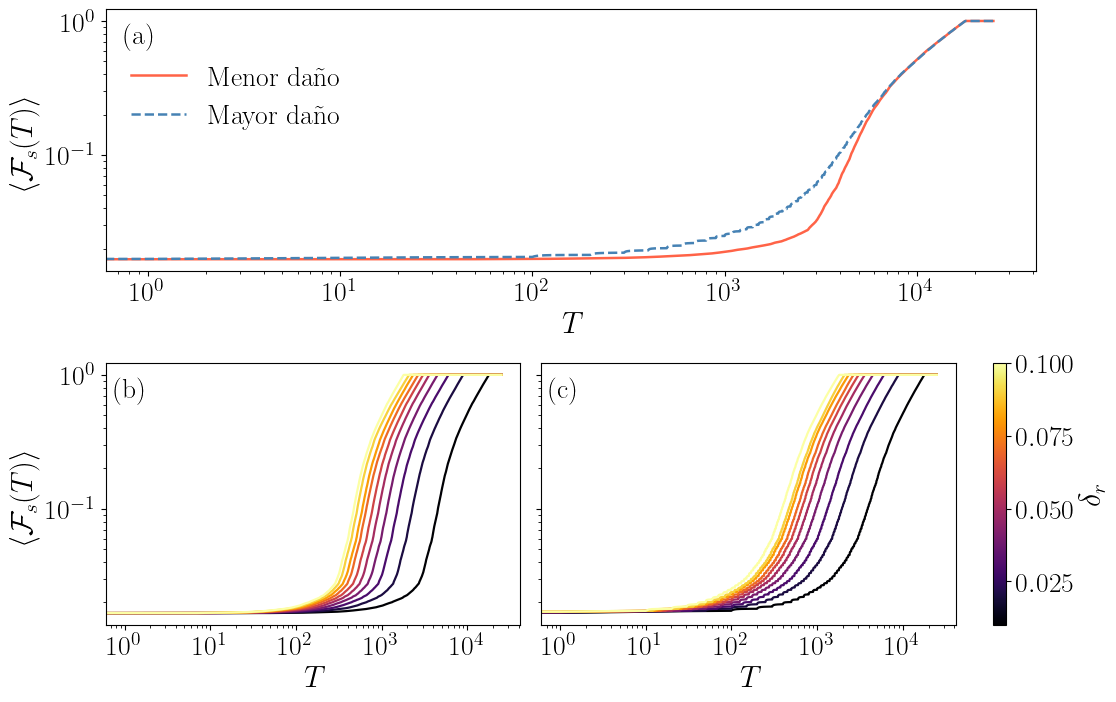

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, NullFormatter

# ==========================================================
# FUNCIÓN AUXILIAR PARA TICKS EN ESCALA LOG
# ==========================================================

def fix_log_ticks(ax, axis="both", numticks=15):
    """
    Fuerza el número de ticks mayores/menores en ejes log-log
    para que no se pierdan al aumentar labelsize.
    """
    axes = []
    if axis in ("x", "both"):
        axes.append(ax.xaxis)
    if axis in ("y", "both"):
        axes.append(ax.yaxis)

    for axi in axes:
        axi.set_major_locator(LogLocator(base=10.0, numticks=numticks))
        axi.set_minor_locator(
            LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=numticks)
        )
        axi.set_minor_formatter(NullFormatter())

# ==========================================================
# PARÁMETROS GENERALES
# ==========================================================

T_repair = 25000
t_repair = np.arange(T_repair + 1)

deltas_r = np.linspace(0.01, 0.10, 10)

colormap = plt.colormaps.get_cmap("inferno")
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# ==========================================================
# FIGURA
# ==========================================================

fig = plt.figure(figsize=(12, 8), facecolor="white")

gs = GridSpec(
    2,
    2,
    figure=fig,
    height_ratios=[1, 1],
    hspace=0.35,
    wspace=0.05
)

# ==========================================================
# (a) Estrategias determinísticas
# ==========================================================

ax1 = fig.add_subplot(gs[0, :])

avg_repair = np.load(
    "F_Deterministic_enlace.npy",
    allow_pickle=True
).item()

strategy_config = {
    "best": ("Menor daño", "tomato", "-", 1.8),
    "worst": ("Mayor daño", "steelblue", "--", 1.8),
}

for s in ["best", "worst"]:

    label, color, style, lw = strategy_config[s]

    ax1.loglog(
        t_repair,
        avg_repair[s],
        linestyle=style,
        color=color,
        linewidth=lw,
        label=label,
    )

ax1.set_xlabel(r"$T$", fontsize=22)
ax1.set_ylabel(r"$\left\langle \mathcal{F}_s(T)\right\rangle$", fontsize=22)

fix_log_ticks(ax1)
ax1.tick_params(axis="both", labelsize=20)

ax1.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 0.88),
    frameon=False,
    fontsize=20
)

ax1.text(
    0.02,
    0.95,
    "(a)",
    transform=ax1.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
)

# ==========================================================
# (b) Menor daño
# ==========================================================

ax2 = fig.add_subplot(gs[1, 0])

avg_best = np.load(
    "F_Deterministic_deltar_enlace_Best.npy",
    allow_pickle=True
).item()

for d in deltas_r:

    ax2.loglog(
        t_repair,
        avg_best[d],
        color=colormap(norm(d)),
        linewidth=1.6,
    )

ax2.set_xlabel(r"$T$", fontsize=22)
ax2.set_ylabel(r"$\left\langle \mathcal{F}_s(T)\right\rangle$", fontsize=22)

fix_log_ticks(ax2)
ax2.tick_params(axis="both", labelsize=20)

ax2.text(
    0.02,
    0.95,
    "(b)",
    transform=ax2.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
)

# ==========================================================
# (c) Mayor daño
# ==========================================================

ax3 = fig.add_subplot(gs[1, 1])

avg_worst = np.load(
    "F_Deterministic_deltar_enlace_Worst.npy",
    allow_pickle=True
).item()

for d in deltas_r:

    ax3.loglog(
        t_repair,
        avg_worst[d],
        color=colormap(norm(d)),
        linewidth=1.6,
    )

ax3.set_xlabel(r"$T$", fontsize=22)

fix_log_ticks(ax3)
ax3.tick_params(axis="both", labelsize=20)
ax3.tick_params(axis="y", labelleft=False)

ax3.text(
    0.02,
    0.95,
    "(c)",
    transform=ax3.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
)

# ==========================================================
# BARRA DE COLOR COMPARTIDA
# ==========================================================

sm = plt.cm.ScalarMappable(
    cmap=colormap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax2, ax3],
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    r"$\delta_r$",
    fontsize=22
)

cbar.ax.tick_params(labelsize=20)

# ==========================================================
# AJUSTE FINAL
# ==========================================================

plt.tight_layout()

plt.savefig(
    "Funcionalidad_Determinista_Completa.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()